# Limpieza de bienes raíces

Este es un conjunto de datos (dataset) reales que fue descargado usando técnicas de web scraping. La data contiene registros de **Fotocasa**, el cual es uno de los sitios más populares de bienes raíces en España. Por favor no hagas esto (web scraping) a no ser que sea para propósitos académicos.

El dataset fue descargado hace algunos años por Henry Navarro y en ningún caso se obtuvo beneficio económico de ello.

Contiene miles de datos de casas reales publicadas en la web www.fotocasa.com. Tu objetivo es extraer tanta información como sea posible con el conocimiento que tienes hasta ahora de ciencia de datos, por ejemplo ¿cuál es la casa más cara en todo el dataset?

Empecemos precisamente con esa pregunta... ¡Buena suerte!

#### Ejercicio 00. Lee el dataset assets/real_estate.csv e intenta visualizar la tabla (★☆☆)

In [3]:
import pandas as pd

# Este archivo CSV contiene puntos y comas en lugar de comas como separadores
ds = pd.read_csv('assets/real_estate.csv', sep=';')
ds.head()
ds.columns  


Index(['Unnamed: 0', 'id_realEstates', 'isNew', 'realEstate_name',
       'phone_realEstate', 'url_inmueble', 'rooms', 'bathrooms', 'surface',
       'price', 'date', 'description', 'address', 'country', 'level1',
       'level2', 'level3', 'level4', 'level5', 'level6', 'level7', 'level8',
       'upperLevel', 'countryId', 'level1Id', 'level2Id', 'level3Id',
       'level4Id', 'level5Id', 'level6Id', 'level7Id', 'level8Id', 'accuracy',
       'latitude', 'longitude', 'zipCode', 'customZone'],
      dtype='object')

#### Ejercicio 01. ¿Cuál es la casa más cara en todo el dataset? (★☆☆)

Imprime la dirección y el precio de la casa seleccionada. Por ejemplo:

`La casa con dirección en Calle del Prado, Nº20 es la más cara y su precio es de 5000000 USD`

In [4]:
import pandas as pd

# Este archivo CSV contiene puntos y comas en lugar de comas como separadores
df = pd.read_csv('assets/real_estate.csv', sep=';')
df
casa_cara =df.loc[(df['price'] == df['price'].max())]
print(casa_cara[['address','price']])

           address    price
13110  El Escorial  8500000


#### Ejercicio 02. ¿Cuál es la casa más barata del dataset? (★☆☆)

Imprime la dirección y el precio de la casa seleccionada. Por ejemplo:

`La casa con dirección en Calle Alcalá, Nº58 es la más barata y su precio es de 12000 USD`

In [5]:
min_price_nonzero = df.loc[df['price'] != 0, 'price'].min()

if pd.isna(min_price_nonzero):
    print("No hay precios distintos de 0 en el dataset.")
else:
    casa_barata = df.loc[df['price'] == min_price_nonzero]
    print(casa_barata[['address', 'price']])


              address  price
7491  Berlin, Coslada    600


#### Ejercicio 03. ¿Cuál es la casa más grande y la más pequeña del dataset? (★☆☆)

Imprime la dirección y el área de las casas seleccionadas. Por ejemplo:

`La casa más grande está ubicada en Calle Gran Vía, Nº38 y su superficie es de 5000 metros`

`La casa más pequeña está ubicada en Calle Mayor, Nº12 y su superficie es de 200 metros`

In [6]:

Casa_mas_grande = df.loc[(df['surface'] == df['surface'].max())]
print(Casa_mas_grande[['address','surface']])
casa_mas_pequeña = df.loc[(df['surface'] == df['surface'].min())]
print(casa_mas_pequeña[['address','surface']])

               address   surface
6794  Sevilla la Nueva  249000.0
                           address  surface
498  Calle Amparo,  Madrid Capital     15.0


#### Ejercicio 04. ¿Cuantas poblaciones (columna level5) contiene el dataset? (★☆☆)

Imprime el nombre de las poblaciones separadas por coma. Por ejemplo:

`> print(populations)`

`population1, population2, population3, ...`

In [7]:
import pandas as pd
df = pd.read_csv('assets/real_estate.csv', sep=';')
df
populations = df['level5'].dropna().astype(str).unique()

print(len(populations))
print(",".join(populations))

168
Arganda del Rey,Fuenlabrada,Boadilla del Monte,Las Rozas de Madrid, Madrid Capital,Villaviciosa de Odón,Pinto,Valdemoro,Navalcarnero,Pozuelo de Alarcón,Torrejón de Ardoz,Navalagamella,San Sebastián de los Reyes,Rivas-vaciamadrid,Alpedrete,Móstoles,San Fernando de Henares,Coslada,Becerril de la Sierra,Alcalá de Henares,Chinchón,Parla,Alcorcón,El Escorial,Leganés,Pedrezuela,Majadahonda,Villanueva de la Cañada,Villanueva del Pardillo,Torrelodones,Moralzarzal,Mejorada del Campo,Aranjuez,Corpa,Getafe,Velilla de San Antonio,Sevilla la Nueva,San Martín de la Vega,Villalbilla,Collado Villalba,Alcobendas,El Molar (Madrid),Moraleja de Enmedio,Algete,Campo Real,Torrejón de la Calzada,Colmenar Viejo,Valdemorillo,Fuente El Saz de Jarama,Tres Cantos,Arroyomolinos (Madrid),Griñón,Paracuellos de Jarama,Guadarrama,Titulcia,Galapagar,Collado Mediano,Los Molinos,San Lorenzo de El Escorial,Loeches,San Martín de Valdeiglesias,Navas del Rey,Bustarviejo,Manzanares El Real,Carabaña,Casarrubuelos,Cercedill

#### Ejercicio 05. ¿El dataset contiene valores no admitidos (NAs)? (★☆☆)

Imprima un booleano (`True` o `False`) seguido de la fila/columna que contiene el NAs.

In [8]:
import pandas as pd
df = pd.read_csv('assets/real_estate.csv', sep=';')
df
print(df.isnull().any().any())

True


#### Ejercicio 06. Elimina los NAs del dataset, si aplica (★★☆)

Imprima una comparación entre las dimensiones del DataFrame original versus el DataFrame después de las eliminaciones.


In [9]:
import pandas as pd
df = pd.read_csv('assets/real_estate.csv', sep=';')
df
df_sin_filas_nan = df.dropna()
print(df)
print(df_sin_filas_nan)
df=df_sin_filas_nan

       Unnamed: 0  id_realEstates  isNew                    realEstate_name  \
0               1       153771986  False            ferrari 57 inmobiliaria   
1               2       153867863  False  tecnocasa fuenlabrada ferrocarril   
2               3       153430440  False                 look find boadilla   
3               4       152776331  False  tecnocasa fuenlabrada ferrocarril   
4               5       153180188  False            ferrari 57 inmobiliaria   
...           ...             ...    ...                                ...   
15330       15331       153901377  False                infocasa consulting   
15331       15332       150394373  False                inmobiliaria pulpon   
15332       15333       153901397  False             tecnocasa torrelodones   
15333       15334       152607440  False                inmobiliaria pulpon   
15334       15335       153901356  False                infocasa consulting   

       phone_realEstate                            

#### Ejercicio 07. ¿Cuál la media de precios en la población (columna level5) de "Arroyomolinos (Madrid)"? (★★☆)

Imprima el valor obtenido.

In [10]:
import pandas as pd
df = pd.read_csv('assets/real_estate.csv', sep=';')

Media_precios = df.loc[(df['level5'] == 'Arroyomolinos (Madrid)')]
print(Media_precios['price'].mean())



294541.59854014596


#### Ejercicio 08. Trazar el histograma de los precios para la población (level5 column) de "Arroyomolinos (Madrid)" y explica qué observas (★★☆)

Imprime el histograma de los precios y escribe en la celda del Markdown un breve análisis del trazado.


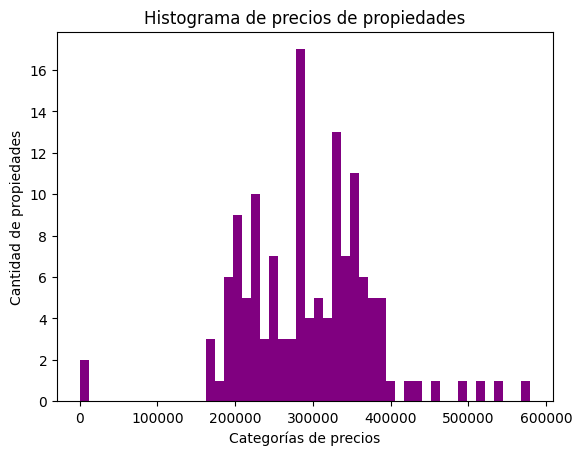

In [11]:
import pandas as pd
df = pd.read_csv('assets/real_estate.csv', sep=';')

import matplotlib.pyplot as plt

Arroyo= df.loc[(df['level5'] == 'Arroyomolinos (Madrid)')] 
plt.hist(Arroyo.price, bins=50, alpha = 1, color='purple')
plt.xlabel('Categorías de precios')
plt.ylabel('Cantidad de propiedades')
plt.title('Histograma de precios de propiedades')
plt.show()


Los precios de la poblacion arroyomolinos se agrupan principalmente entre los 200.000 y los 400.000 dolares donde la tendencia el precio más popular es de 300.000

#### Ejercicio 09. ¿Son los precios promedios de "Valdemorillo" y "Galapagar" los mismos? (★★☆)

Imprime ambos promedios y escribe una conclusión sobre ellos.

In [12]:
import pandas as pd
df = pd.read_csv('assets/real_estate.csv', sep=';')
Media_precios_Valdemorillo = df.loc[(df['level5'] == 'Valdemorillo')]
Media_precios_Galapar = df.loc[(df['level5'] == 'Galapagar')]
print("Media de precios en Valdemorillo:")
print(Media_precios_Valdemorillo['price'].mean())
print("Media de precios en Galapagar:")
print(Media_precios_Galapar['price'].mean())
print("Diferencia de precios entre Valdemorillo y Galapagar:")
diferencia = abs(Media_precios_Valdemorillo['price'].mean() - Media_precios_Galapar['price'].mean())
print(diferencia.round(2))



Media de precios en Valdemorillo:
363860.2931034483
Media de precios en Galapagar:
360063.20238095237
Diferencia de precios entre Valdemorillo y Galapagar:
3797.09


El promedio de cada uno no son lo mismo, pero son bastantes cercanos, tienen una diferencia de 3797.09

#### Ejercicio 10. ¿Son los promedios de precio por metro cuadrado (precio/m2) de "Valdemorillo" y "Galapagar" los mismos? (★★☆)

Imprime ambos promedios de precio por metro cuadrado y escribe una conclusión sobre ellos.

Pista: Crea una nueva columna llamada `pps` (*price per square* o precio por metro cuadrado) y luego analiza los valores.

In [13]:
import pandas as pd
df = pd.read_csv('assets/real_estate.csv', sep=';')
Valdemorillo = df.loc[(df['level5'] == 'Valdemorillo')]
Galapagar = df.loc[(df['level5'] == 'Galapagar')]
pps_Valdemorillo =(Valdemorillo['price']*1000/Valdemorillo['surface'])
pps_Galapagar = (Galapagar['price']*1000/Galapagar['surface']) 

print("Media de precio x m2 en Valdemorillo:")
print(pps_Valdemorillo.mean().round(2))
print("Media de precios x m2 en Galapagar:")
print(pps_Galapagar.mean().round(2))

print("Diferencia de precio x m2 entre Valdemorillo y Galapagar:")
diferencia_m2 = abs((Valdemorillo['price']*1000/Valdemorillo['surface']).mean() - (Galapagar['price']*1000/Galapagar['surface']).mean())
print(diferencia_m2.round(2))



Media de precio x m2 en Valdemorillo:
1317950.21
Media de precios x m2 en Galapagar:
1606324.03
Diferencia de precio x m2 entre Valdemorillo y Galapagar:
288373.82


En Galapagar el metro cuadrado está más caro que en Valdemorillo, con una diferencia de 288.373

#### Ejercicio 11. Analiza la relación entre la superficie y el precio de las casas. (★★☆)

Pista: Puedes hacer un `scatter plot` y luego escribir una conclusión al respecto.

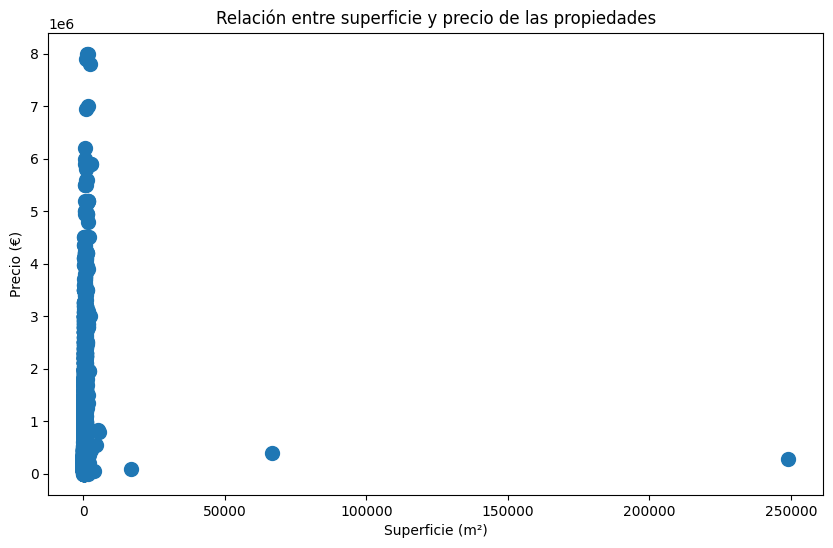

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('assets/real_estate.csv', sep=';')
df.dropna(subset=['surface', 'price'], inplace=True)

plt.figure(figsize=(10,6))
plt.scatter(df['surface'], df['price'], s=100)
plt.title('Relación entre superficie y precio de las propiedades')
plt.xlabel('Superficie (m²)')
plt.ylabel('Precio (€)')
plt.show()

**TODO: Markdown**. Para escribir aquí, haz doble clic en esta celda, elimina este contenido y coloca lo que quieras escribir. Luego ejecuta la celda.

#### Ejercicio 12. ¿Cuántas agencia de bienes raíces contiene el dataset? (★★☆)

Imprime el valor obtenido.

In [15]:

df['id_realEstates'].nunique()


13043

#### Ejercicio 13. ¿Cuál es la población (columna level5) que contiene la mayor cantidad de casas?(★★☆)

Imprima la población y el número de casas.

In [16]:
suma_por_categoria = df.groupby('level5').count()
print(suma_por_categoria['Unnamed: 0'].sort_values(ascending=False))

level5
 Madrid Capital               6237
Alcalá de Henares              499
Las Rozas de Madrid            373
Móstoles                       284
San Sebastián de los Reyes     264
                              ... 
Montejo de la Sierra             1
Lozoya                           1
Pinilla del Valle                1
Rascafría                        1
Piñuécar-gandullas               1
Name: Unnamed: 0, Length: 168, dtype: int64


#### Ejercicio 14. Ahora vamos a trabajar con el "cinturón sur" de Madrid. Haz un subconjunto del DataFrame original que contenga las siguientes poblaciones (columna level5): "Fuenlabrada", "Leganés", "Getafe", "Alcorcón" (★★☆)

Pista: Filtra el DataFrame original usando la columna `level5` y la función `isin`.

In [17]:
subconjunto =['Fuenlabrada', 'Getafe', 'Leganés','Alcorcón']
cinturon_sur = df[df['level5'].isin(subconjunto)].copy()
(cinturon_sur)

,Unnamed: 0,id_realEstates,isNew,realEstate_name,phone_realEstate,url_inmueble,rooms,bathrooms,surface,price,...,level4Id,level5Id,level6Id,level7Id,level8Id,accuracy,latitude,longitude,zipCode,customZone
3,4,152776331,False,tecnocasa fuenlabrada ferrocarril,916358736.0,https://www.fotocasa.es/es/comprar/vivienda/ma...,3.0,1.0,86.0,89000,...,0,0,0,0,0,0,"40,2853785786438","-3,79508142135624",NaN,NaN
85,86,153152077,False,sinergical inmobiliaria,NaN,https://www.fotocasa.es/es/comprar/vivienda/le...,1.0,1.0,50.0,107000,...,0,0,0,0,0,1,"40,35059","-3,82693",NaN,NaN
94,95,153995577,False,viviendas365com,911226014.0,https://www.fotocasa.es/es/comprar/vivienda/le...,3.0,2.0,120.0,320000,...,0,0,0,0,0,0,"40,31933","-3,77574",NaN,NaN
109,110,153586414,False,area uno asesores inmobiliarios,912664081.0,https://www.fotocasa.es/es/comprar/vivienda/ma...,3.0,3.0,142.0,425000,...,0,0,0,0,0,0,"40,3313411","-3,8313868",NaN,NaN
161,162,153440116,False,prolucisa,916350416.0,https://www.fotocasa.es/es/comprar/vivienda/ma...,3.0,2.0,123.0,239500,...,0,0,0,0,0,0,"40,2744807718156","-3,79192471504211",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15275,15276,153903887,False,aliseda servicios de gestion inmobiliaria,911368198.0,https://www.fotocasa.es/es/comprar/vivienda/al...,3.0,1.0,78.0,138000,...,0,0,0,0,0,1,"40,31381","-3,83733",NaN,NaN
15291,15292,151697757,False,unipiso,912788631.0,https://www.fotocasa.es/es/comprar/vivienda/al...,3.0,2.0,110.0,279000,...,0,0,0,0,0,0,"40,3259051","-3,76318",NaN,NaN
15305,15306,153902389,False,jadein ferrero,914871639.0,https://www.fotocasa.es/es/comprar/vivienda/ma...,3.0,2.0,85.0,170000,...,0,0,0,0,0,0,"40,2882193","-3,8098617",NaN,NaN
15322,15323,153871864,False,gestion comercial,911220662.0,https://www.fotocasa.es/es/comprar/vivienda/ma...,3.0,1.0,91.0,112000,...,0,0,0,0,0,0,"40,28282","-3,78892",NaN,NaN


#### Ejercicio 15. Traza un gráfico de barras de la mediana de los precios y explica lo que observas (debes usar el subconjunto obtenido del Ejercicio 14) (★★★)

Imprima un gráfico de barras de la mediana de precios y escriba en la celda Markdown un breve análisis sobre el gráfico.

level5
Fuenlabrada    157000.0
Getafe         269000.0
Leganés        170000.0
Alcorcón       181000.0
Name: price, dtype: float64


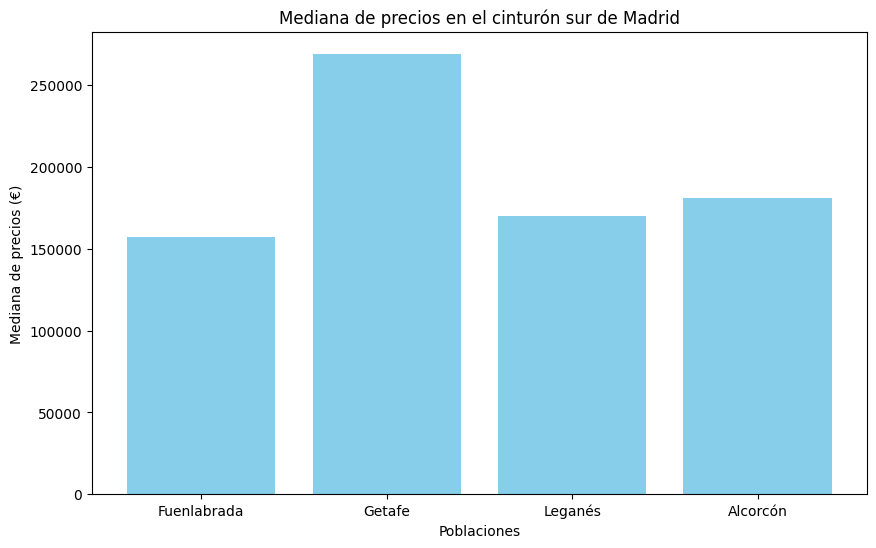

In [18]:
median =cinturon_sur.groupby('level5')['price'].median().reindex(subconjunto)
print(median)

plt.figure(figsize=(10,6))
plt.bar(subconjunto, median, color='skyblue', width=0.8)
plt.title('Mediana de precios en el cinturón sur de Madrid')
plt.xlabel('Poblaciones')
plt.ylabel('Mediana de precios (€)')
plt.show()

La mediana más alta de todas las poblaciones, es la Getafe, donde es 269.000 mil euros.

#### Ejercicio 16. Calcula la media y la varianza de muestra para las siguientes variables: precio, habitaciones, superficie y baños (debes usar el subconjunto obtenido del Ejercicio 14) (★★★)

Imprime ambos valores por cada variable.

In [19]:
media = cinturon_sur.groupby('level5')[['price','rooms','surface','bathrooms']].mean().round(2).reindex(subconjunto)
print(media)
varianza = cinturon_sur.groupby('level5')[['price','rooms','surface','bathrooms']].var().round(2).reindex(subconjunto)
print(varianza)

cs=cinturon_sur


                 price  rooms  surface  bathrooms
level5                                           
Fuenlabrada  180955.43   3.03   103.62       1.47
Getafe       254106.41   3.14   126.90       1.83
Leganés      210794.38   2.91   105.85       1.54
Alcorcón     235453.76   2.90   105.91       1.65
                    price  rooms  surface  bathrooms
level5                                              
Fuenlabrada  4.889574e+09   0.39  2264.64       0.36
Getafe       2.196437e+10   0.64  5828.11       0.64
Leganés      1.232968e+10   0.82  3987.48       0.58
Alcorcón     1.685789e+10   1.01  4244.32       0.62


#### Ejercicio 17. ¿Cuál es la casa más cara de cada población? Debes usar el subset obtenido en la pregunta 14 (★★☆)

Imprime tanto la dirección como el precio de la casa seleccionada de cada población. Puedes imprimir un DataFrame o una sola línea para cada población.

In [42]:
casa_mas_cara=cs.groupby('level5')['price'].max().reindex(subconjunto)
#cs[cs['price']==490000]
sub_4=cs[cs['price'].isin(casa_mas_cara)]
sub_4[['address','level5','price']]
   




,address,level5,price
2881,Getafe,Getafe,1050000
5585,Alcorcón,Alcorcón,950000
10412,"Avenida Reina Sofía, Leganés",Leganés,650000
11561,"Calle de Paulo Freire, 5, Fuenlabrada",Fuenlabrada,490000


#### Ejercicio 18. Normaliza la variable de precios para cada población y traza los 4 histogramas en el mismo gráfico (debes usar el subconjunto obtenido en la pregunta 14) (★★★)

Para el método de normalización, puedes usar el que consideres adecuado, no hay una única respuesta correcta para esta pregunta. Imprime el gráfico y escribe en la celda de Markdown un breve análisis sobre el gráfico.

Pista: Puedes ayudarte revisando la demostración multihist de Matplotlib.

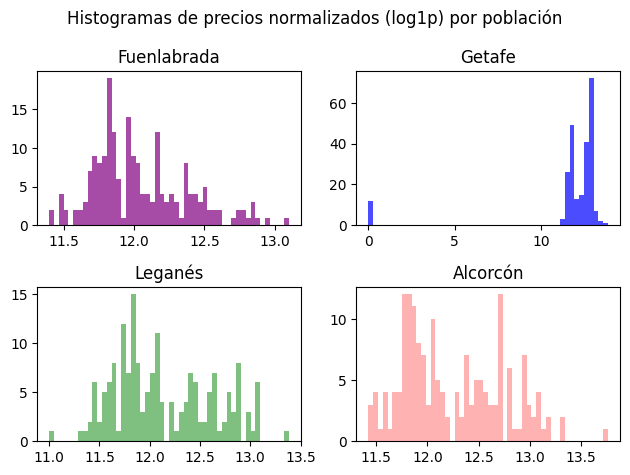

In [82]:
import numpy as np
p1=cs[cs['level5']=='Fuenlabrada']
p1
p1_normalizado=np.log1p(p1['price'])


p2=cs[cs['level5']=='Getafe']
p2_normalizado=np.log1p(p2['price'])
p3=cs[cs['level5']=='Leganés']
p3_normalizado=np.log1p(p3['price'])
p4=cs[cs['level5']=='Alcorcón']
p4_normalizado=np.log1p(p4['price'])

fig, ax =plt.subplots(2,2)
ax[0,0].hist(p1_normalizado, bins=50, alpha = 0.7, color='purple')
ax[0,0].set_title('Fuenlabrada')
ax[0,1].set_title('Getafe')
ax[1,0].set_title('Leganés')
ax[1,1].set_title('Alcorcón')
ax[0,1].hist(p2_normalizado, bins=50, alpha = 0.7, color='blue')
ax[1,0].hist(p3_normalizado, bins=50, alpha = 0.5, color='green')
ax[1,1].hist(p4_normalizado, bins=50, alpha = 0.3, color='red')
plt.suptitle('Histogramas de precios normalizados (log1p) por población')
plt.tight_layout()
plt.show()



**TODO: Markdown**. Para escribir aquí, haz doble clic en esta celda, elimina este contenido y coloca lo que quieras escribir. Luego ejecuta la celda.

#### Ejercicio 19. ¿Qué puedes decir sobre el precio por metro cuadrado (precio/m2) entre los municipios de 'Getafe' y 'Alcorcón'? Debes usar el subconjunto obtenido en la pregunta 14 (★★☆)

Pista: Crea una nueva columna llamada `pps` (price per square en inglés) y luego analiza los valores

Media precio x m2 en Getafe:
2066314.95
Media precios x m2 en Alcorcón:
2239302.48


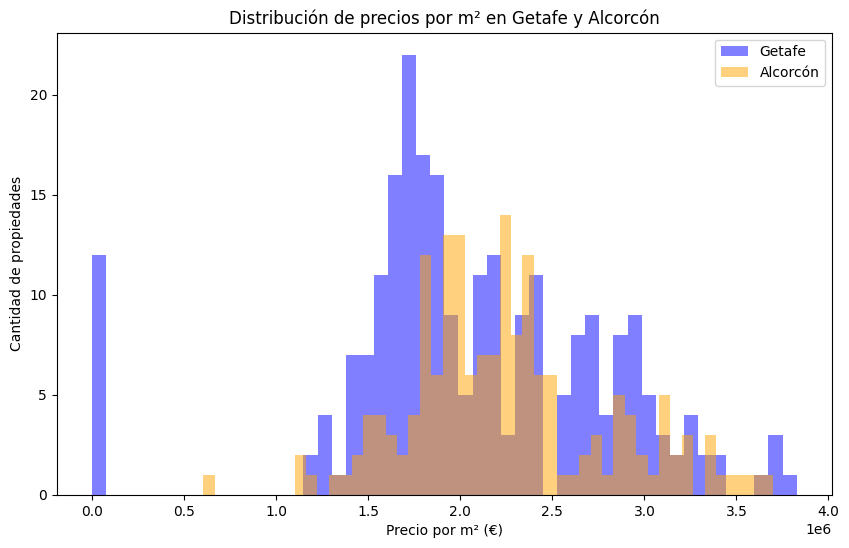

In [39]:
Getafe =cs.loc[(cs['level5'] == 'Getafe')]
Alcorcon =cs.loc[(cs['level5'] == 'Alcorcón')]
pps_Getafe= (Getafe['price']*1000/Getafe['surface'])
pps_Alcorcon = (Alcorcon['price']*1000/Alcorcon['surface'])
#print("Precio x m2 en Getafe:")
#print(pps_Getafe.round(2))
#print("Precios x m2 en Alcorcón:")
#print(pps_Alcorcon.round(2))

print("Media precio x m2 en Getafe:")
print(pps_Getafe.mean().round(2))
print("Media precios x m2 en Alcorcón:")
print(pps_Alcorcon.mean().round(2))

plt.figure(figsize=(10,6))
plt.hist(pps_Getafe, bins=50, alpha=0.5, label='Getafe', color='blue')
plt.hist(pps_Alcorcon, bins=50, alpha=0.5, label='Alcorcón', color='orange')
plt.xlabel('Precio por m² (€)')
plt.ylabel('Cantidad de propiedades')
plt.title('Distribución de precios por m² en Getafe y Alcorcón')
plt.legend()
plt.show()

Las propiedades en Getafe son más cara por mt2

#### Ejercicio 20. Realiza el mismo gráfico para 4 poblaciones diferentes (columna level5) y colócalos en el mismo gráfico. Debes usar el subconjunto obtenido en la pregunta 14 (★★☆) 
Pista: Haz un diagrama de dispersión de cada población usando subgráficos (subplots).

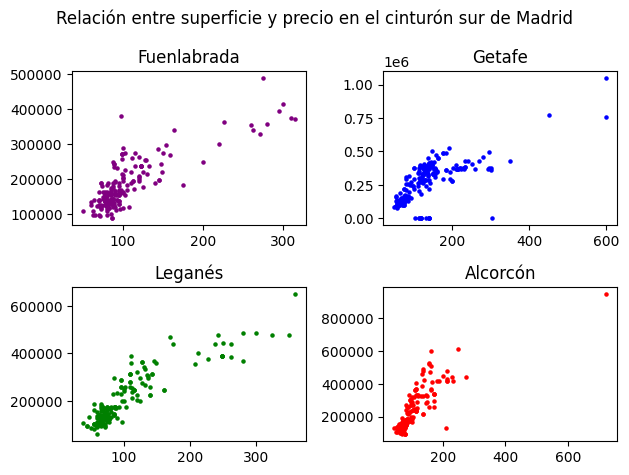

In [89]:
fig,ax=plt.subplots(2,2)
ax[0,0].scatter(p1['surface'], p1['price'], s=5, color='purple')
ax[0,0].set_title('Fuenlabrada')
ax[0,1].scatter(p2['surface'], p2['price'], s=5, color='blue')
ax[0,1].set_title('Getafe')
ax[1,0].scatter(p3['surface'], p3['price'], s=5, color='green')
ax[1,0].set_title('Leganés')
ax[1,1].scatter(p4['surface'], p4['price'], s=5, color='red')
ax[1,1].set_title('Alcorcón')
plt.suptitle('Relación entre superficie y precio en el cinturón sur de Madrid')
plt.tight_layout()
plt.show()

#### Ejercicio 21. Realiza un trazado de las coordenadas (columnas latitud y longitud) del cinturón sur de Madrid por color de cada población (debes usar el subconjunto obtenido del Ejercicio 14) (★★★★)

Ejecuta la siguiente celda y luego comienza a codear en la siguiente. Debes implementar un código simple que transforme las columnas de coordenadas en un diccionario de Python (agrega más información si es necesario) y agrégala al mapa.

In [90]:
from ipyleaflet import Map, Marker, basemaps, Polygon, Polyline

# Mapa centrado en Madrid
map = Map(center = (40.35, -3.8), zoom = 11.5, min_zoom = 1, max_zoom = 20, 
    basemap=basemaps.OpenStreetMap.Mapnik)
map

Map(center=[40.35, -3.8], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_ou…

In [91]:
## Aquí: traza la coordenadas de los estados
print(subconjunto)

cs_getafe=cs.loc[(cs['level5'] == 'Getafe')]
coor_getafe=cs_getafe[['latitude','longitude']] 
print(coor_getafe)

cs_Fuen=cs.loc[(cs['level5'] == 'Fuenlabrada')]
coor_Fuen=cs_Fuen[['latitude','longitude']]
print(coor_Fuen)


## PON TU CÓDIGO AQUÍ:


polygon = Polygon(
    locations=[(40.31111,-3.73066),(40.3060558,-3.7346649),(40.3035689,-3.7381336)],
    color="blue",
    fill="false"
)
map.add_layer(polygon)  


['Fuenlabrada', 'Getafe', 'Leganés', 'Alcorcón']
         latitude   longitude
169      40,31111    -3,73066
232    40,3060558  -3,7346649
233    40,3035689  -3,7381336
269    40,3068987   -3,725108
381      40,28327    -3,74772
...           ...         ...
14999    40,30546    -3,75275
15002    40,30206    -3,73321
15034    40,31667    -3,74072
15087    40,30186    -3,73321
15117    40,31667    -3,74072

[241 rows x 2 columns]
               latitude          longitude
3      40,2853785786438  -3,79508142135624
161    40,2744807718156  -3,79192471504211
214    40,2906814213562  -3,80405242135624
219       40,3152529585      -3,8365174323
230          40,2921796          -3,815865
...                 ...                ...
15274          40,31381           -3,83733
15275          40,31381           -3,83733
15305        40,2882193         -3,8098617
15322          40,28282           -3,78892
15325          40,28062           -3,79869

[197 rows x 2 columns]


TraitError: The 'fill' trait of a Polygon instance expected a boolean, not the str 'false'.